# VP-SDE диффузия на звёздочке

Реализация Variance-Preserving SDE диффузионной модели:
- Линейное и косинусное расписания β(t)
- Параметризация через денойзинг (модель предсказывает шум ε)
- Сравнение разных вариантов перевзвешивания лосса по t

In [1]:
import math

import torch
import torch.nn as nn
from torch import optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

import numpy as np
import matplotlib.pyplot as plt

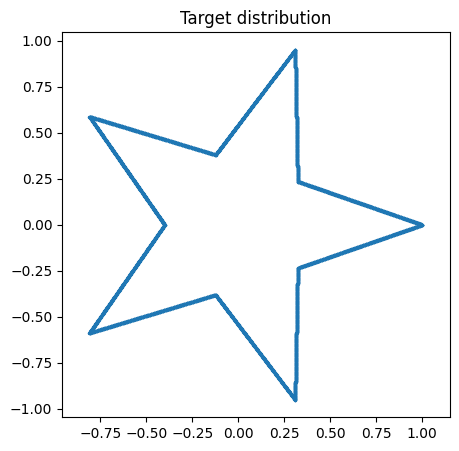

In [2]:
def generate_star(n_spikes=5, inner_radius=0.4, outer_radius=1.0, n_samples=1000, center=(0, 0)):
    angle_step = np.pi / n_spikes

    vertices = []
    for i in range(2 * n_spikes):
        angle = i * angle_step
        radius = outer_radius if i % 2 == 0 else inner_radius

        x = radius * np.cos(angle) + center[0]
        y = radius * np.sin(angle) + center[1]
        vertices.append([x, y])
    vertices.append(vertices[0])

    vertices = np.array(vertices)
    sampled_points = []

    for i in range(len(vertices) - 1):
        start_point = vertices[i]
        end_point = vertices[i + 1]

        for t in np.linspace(0, 1, n_samples // (len(vertices) - 1)):
            point = (1 - t) * start_point + t * end_point
            sampled_points.append(point)

    return np.array(sampled_points)


target = generate_star(n_samples=5000)
plt.figure(figsize=(5, 5))
plt.scatter(target[:, 0], target[:, 1], s=2)
plt.title('Target distribution')
plt.axis('equal')
plt.show()

In [3]:
class Config:
    beta_min = 0.1
    beta_max = 20.0

    lr = 1e-3
    epochs = 1000
    batch_size = 512
    hidden_dim = 256
    num_timesteps = 1000
    data_samples = 5000

## Расписания β(t) и ᾱ(t)

VP-SDE: dx = -½β(t)x dt + √β(t) dw, маргиналы p(x_t|x_0) = N(√ᾱ(t)·x_0, (1−ᾱ(t))·I).

**Линейное:** β(t) = β_min + t·(β_max − β_min), отсюда ᾱ(t) = exp(−β_min·t − ½(β_max − β_min)·t²).

**Косинусное (Nichol & Dhariwal):** ᾱ(t) = cos²((t+s)/(1+s) · π/2) / cos²(s/(1+s) · π/2), а β(t) = −d/dt log ᾱ(t) = π/(1+s) · tan((t+s)/(1+s) · π/2).

In [4]:
def beta_linear(t, config):
    return config.beta_min + t * (config.beta_max - config.beta_min)

def alpha_bar_linear(t, config, eps=1e-5):
    val = torch.exp(-config.beta_min * t - 0.5 * (config.beta_max - config.beta_min) * t ** 2)
    return torch.clamp(val, eps, 1.0 - eps)

def alpha_bar_cosine(t, s=0.008, eps=1e-5):
    f = torch.cos((t + s) / (1 + s) * math.pi / 2) ** 2
    f0 = math.cos(s / (1 + s) * math.pi / 2) ** 2
    return torch.clamp(f / f0, eps, 1.0 - eps)

def beta_cosine(t, s=0.008, clip=20.0):
    beta = math.pi / (1 + s) * torch.tan((t + s) / (1 + s) * math.pi / 2)
    return torch.clamp(beta, max=clip)

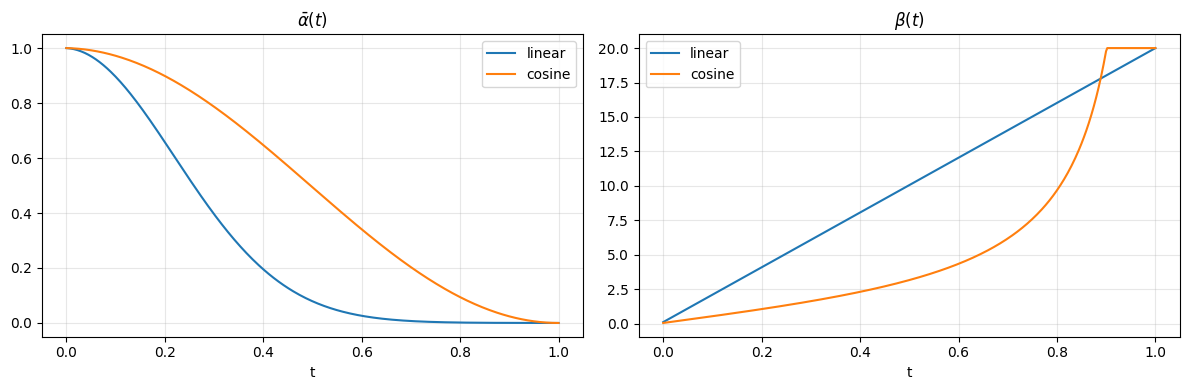

In [5]:
config = Config()
ts = torch.linspace(1e-4, 1.0 - 1e-4, 400)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(ts.numpy(), alpha_bar_linear(ts, config).numpy(), label='linear')
ax1.plot(ts.numpy(), alpha_bar_cosine(ts).numpy(), label='cosine')
ax1.set_title(r'$\bar{\alpha}(t)$')
ax1.set_xlabel('t')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(ts.numpy(), beta_linear(ts, config).numpy(), label='linear')
ax2.plot(ts.numpy(), beta_cosine(ts).numpy(), label='cosine')
ax2.set_title(r'$\beta(t)$')
ax2.set_xlabel('t')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [6]:
class ScoreModel(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config

        self.time_embed = nn.Sequential(
            nn.Linear(1, config.hidden_dim),
            nn.ReLU(),
            nn.Linear(config.hidden_dim, config.hidden_dim),
        )

        self.net = nn.Sequential(
            nn.Linear(2 + config.hidden_dim, config.hidden_dim),
            nn.ReLU(),
            nn.Linear(config.hidden_dim, config.hidden_dim),
            nn.ReLU(),
            nn.Linear(config.hidden_dim, 2),
        )

    def forward(self, x, t):
        t_embed = self.time_embed(t)
        x_input = torch.cat([x, t_embed], dim=1)
        return self.net(x_input)

## Варианты перевзвешивания лосса

Базовый лосс — MSE между предсказанным и истинным шумом ε. Перевзвешивание w(t):

- **uniform**: w = 1 (стандартный DDPM L_simple)
- **snr**: w = clamp(SNR(t), max=5), где SNR(t) = ᾱ/(1−ᾱ) — фокус на низкошумных шагах
- **min_snr_5**: w = min(1, γ/SNR(t)) с γ=5 (Hang et al. 2023) — режет вклад низкошумных шагов
- **likelihood**: w = β(t) — ELBO-подобное взвешивание (фокус на высокошумных шагах)

In [7]:
def weight_uniform(alpha_bar, beta, t):
    return torch.ones_like(t)

def weight_snr(alpha_bar, beta, t):
    return torch.clamp(alpha_bar / (1.0 - alpha_bar + 1e-5), max=5.0)

def weight_min_snr(alpha_bar, beta, t, gamma=5.0):
    snr = alpha_bar / (1.0 - alpha_bar + 1e-5)
    return torch.minimum(torch.ones_like(snr), gamma / snr)

def weight_likelihood(alpha_bar, beta, t):
    return beta

In [8]:
class VPTrainer:
    def __init__(self, config, schedule='linear', weight_fn=weight_uniform):
        self.config = config
        self.schedule = schedule
        self.weight_fn = weight_fn
        self.device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

        star = generate_star(n_samples=config.data_samples)
        self.data = torch.tensor(star, dtype=torch.float32)
        self.dataset = TensorDataset(self.data)
        self.dataloader = DataLoader(self.dataset, batch_size=config.batch_size, shuffle=True)

        self.model = ScoreModel(config).to(self.device)
        self.optimizer = optim.Adam(self.model.parameters(), lr=config.lr)
        self.losses = []

        if schedule == 'linear':
            self.alpha_bar_fn = lambda t: alpha_bar_linear(t, config)
            self.beta_fn = lambda t: beta_linear(t, config)
        elif schedule == 'cosine':
            self.alpha_bar_fn = alpha_bar_cosine
            self.beta_fn = beta_cosine
        else:
            raise ValueError(schedule)

    def train_epoch(self):
        self.model.train()
        total_loss = 0.0

        for (batch,) in self.dataloader:
            batch = batch.to(self.device)

            t = torch.rand(batch.shape[0], 1, device=self.device) * (1.0 - 2e-5) + 1e-5
            alpha_bar = self.alpha_bar_fn(t)
            beta = self.beta_fn(t)

            z = torch.randn_like(batch)
            x_t = torch.sqrt(alpha_bar) * batch + torch.sqrt(1.0 - alpha_bar) * z

            pred_z = self.model(x_t, t)
            w = self.weight_fn(alpha_bar, beta, t)
            loss = (w * (pred_z - z) ** 2).mean()

            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()

            total_loss += loss.item() * batch.shape[0]

        return total_loss / len(self.data)

    def run(self, log_every=200):
        for n in range(self.config.epochs):
            loss = self.train_epoch()
            self.losses.append(loss)
            if n % log_every == 0:
                print(f'  epoch {n:>4}: loss={loss:.5f}')
        return self.losses

## Семплирование (reverse-time SDE)

Reverse VP-SDE: dx = [−½β(t)·x − β(t)·∇log p_t(x)] dt + √β(t) dw̄.

В дискретном Эйлер-Маруяме (идём от t=1 к t=0 шагом Δt):

x_{t−Δt} = x_t + [½β(t)·x_t + β(t)·s_θ(x_t, t)] · Δt + √(β(t)·Δt) · z

где score через denoising-параметризацию: s_θ(x, t) = −ε_θ(x, t) / √(1 − ᾱ(t)).

In [9]:
def sample_vp(model, alpha_bar_fn, beta_fn, config, num_samples=1000):
    device = next(model.parameters()).device
    model.eval()

    with torch.no_grad():
        x = torch.randn(num_samples, 2, device=device)
        dt = 1.0 / config.num_timesteps

        for i in range(config.num_timesteps):
            t = max(1.0 - i * dt, 1e-5)
            t_tensor = torch.full((num_samples, 1), t, device=device)

            alpha_bar = alpha_bar_fn(t_tensor)
            beta = beta_fn(t_tensor)

            pred_eps = model(x, t_tensor)
            score = -pred_eps / torch.sqrt(1.0 - alpha_bar)

            drift = (0.5 * beta * x + beta * score) * dt
            x = x + drift
            if i < config.num_timesteps - 1:
                x = x + torch.sqrt(beta * dt) * torch.randn_like(x)

    return x.cpu().numpy()

## Обучение всех конфигураций (2 расписания × 4 веса)

In [10]:
schedules = ['linear', 'cosine']
weight_fns = {
    'uniform': weight_uniform,
    'snr': weight_snr,
    'min_snr_5': weight_min_snr,
    'likelihood': weight_likelihood,
}

results = {}
for sch in schedules:
    for wn, wf in weight_fns.items():
        tag = f'{sch}_{wn}'
        print(f'\n>>> {tag}')
        config = Config()
        trainer = VPTrainer(config, schedule=sch, weight_fn=wf)
        trainer.run()
        samples = sample_vp(trainer.model, trainer.alpha_bar_fn, trainer.beta_fn, config, num_samples=2000)
        results[tag] = {
            'losses': trainer.losses,
            'samples': samples,
            'final_loss': trainer.losses[-1],
        }
        print(f'  final loss: {trainer.losses[-1]:.5f}')


>>> linear_uniform
  epoch    0: loss=0.83243
  epoch  200: loss=0.16518
  epoch  400: loss=0.14694
  epoch  600: loss=0.15433
  epoch  800: loss=0.15351
  final loss: 0.15602

>>> linear_snr
  epoch    0: loss=0.96599
  epoch  200: loss=0.62938
  epoch  400: loss=0.56769
  epoch  600: loss=0.59012
  epoch  800: loss=0.53052
  final loss: 0.54655

>>> linear_min_snr_5
  epoch    0: loss=0.75457
  epoch  200: loss=0.09835
  epoch  400: loss=0.09566
  epoch  600: loss=0.09501
  epoch  800: loss=0.09450
  final loss: 0.09198

>>> linear_likelihood
  epoch    0: loss=8.49471
  epoch  200: loss=0.46427
  epoch  400: loss=0.46981
  epoch  600: loss=0.43530
  epoch  800: loss=0.42585
  final loss: 0.43782

>>> cosine_uniform
  epoch    0: loss=0.89549
  epoch  200: loss=0.28696
  epoch  400: loss=0.27359
  epoch  600: loss=0.28229
  epoch  800: loss=0.28145
  final loss: 0.27505

>>> cosine_snr
  epoch    0: loss=1.85903
  epoch  200: loss=1.14915
  epoch  400: loss=1.15623
  epoch  600: los

## Визуализация сгенерированных сэмплов

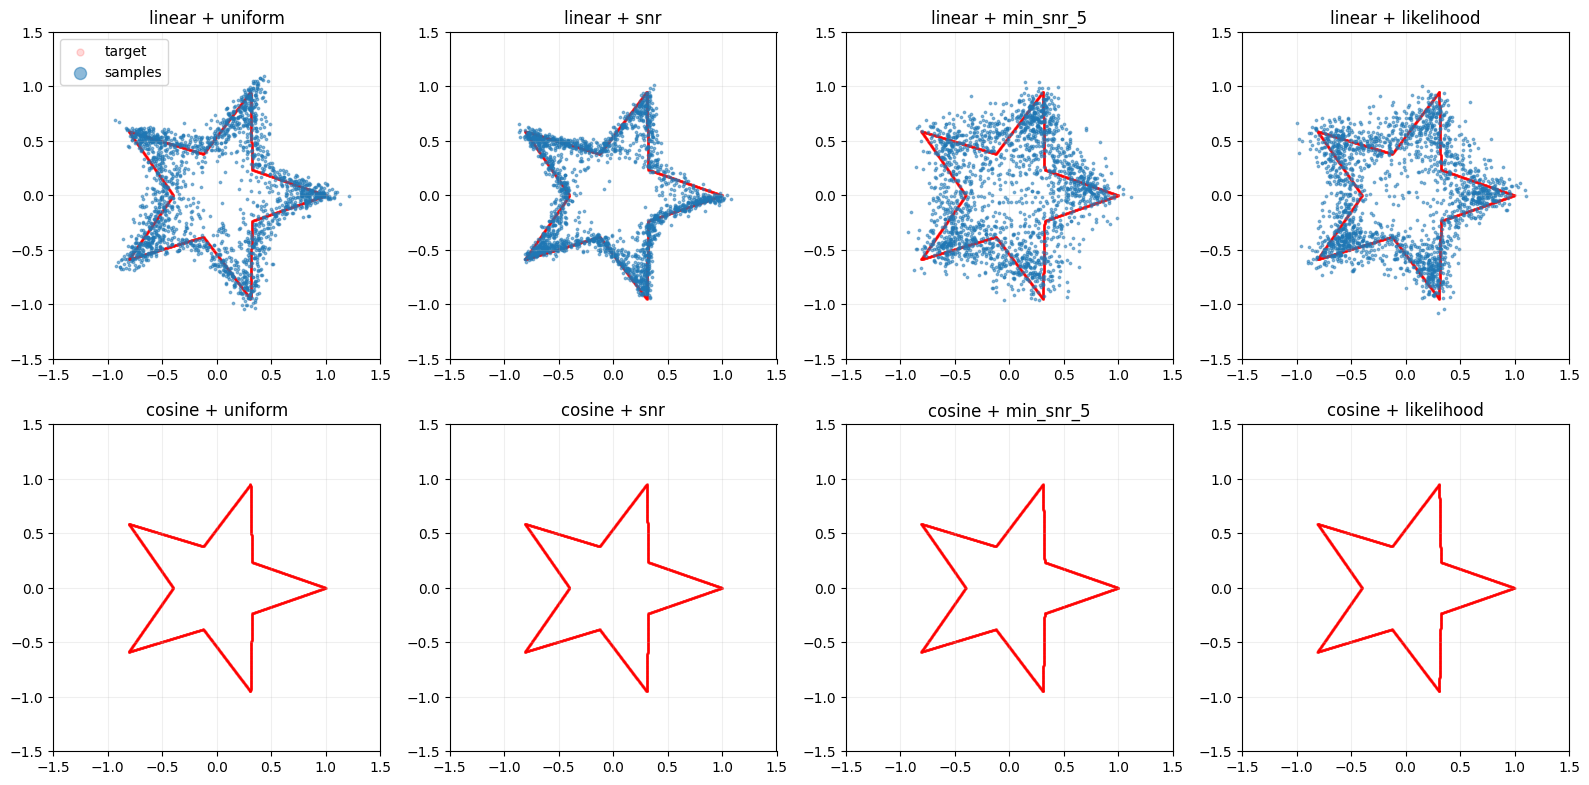

In [11]:
weight_names = list(weight_fns.keys())

fig, axes = plt.subplots(len(schedules), len(weight_names), figsize=(4 * len(weight_names), 4 * len(schedules)))

for r, sch in enumerate(schedules):
    for c, wn in enumerate(weight_names):
        ax = axes[r][c]
        pts = results[f'{sch}_{wn}']['samples']
        ax.scatter(target[:, 0], target[:, 1], s=1, alpha=0.15, c='red', label='target')
        ax.scatter(pts[:, 0], pts[:, 1], s=3, alpha=0.5, c='C0', label='samples')
        ax.set_title(f'{sch} + {wn}')
        ax.set_xlim(-1.5, 1.5)
        ax.set_ylim(-1.5, 1.5)
        ax.set_aspect('equal')
        ax.grid(alpha=0.2)
        if r == 0 and c == 0:
            ax.legend(markerscale=5)

plt.tight_layout()
plt.show()

## Кривые лосса

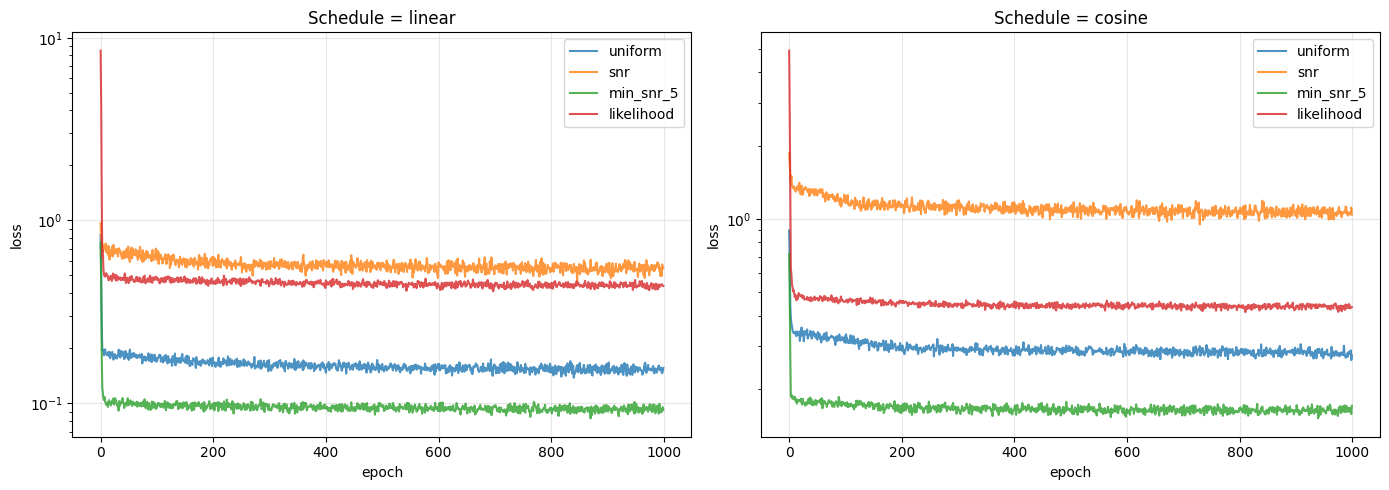

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax_i, sch in enumerate(schedules):
    for wn in weight_names:
        axes[ax_i].plot(results[f'{sch}_{wn}']['losses'], label=wn, alpha=0.8)
    axes[ax_i].set_title(f'Schedule = {sch}')
    axes[ax_i].set_xlabel('epoch')
    axes[ax_i].set_ylabel('loss')
    axes[ax_i].set_yscale('log')
    axes[ax_i].legend()
    axes[ax_i].grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Сравнение по весам — построчно

те же сэмплы построчно по схемам перевзвешивания, чтобы было видно, что меняет каждый вес независимо от расписания.

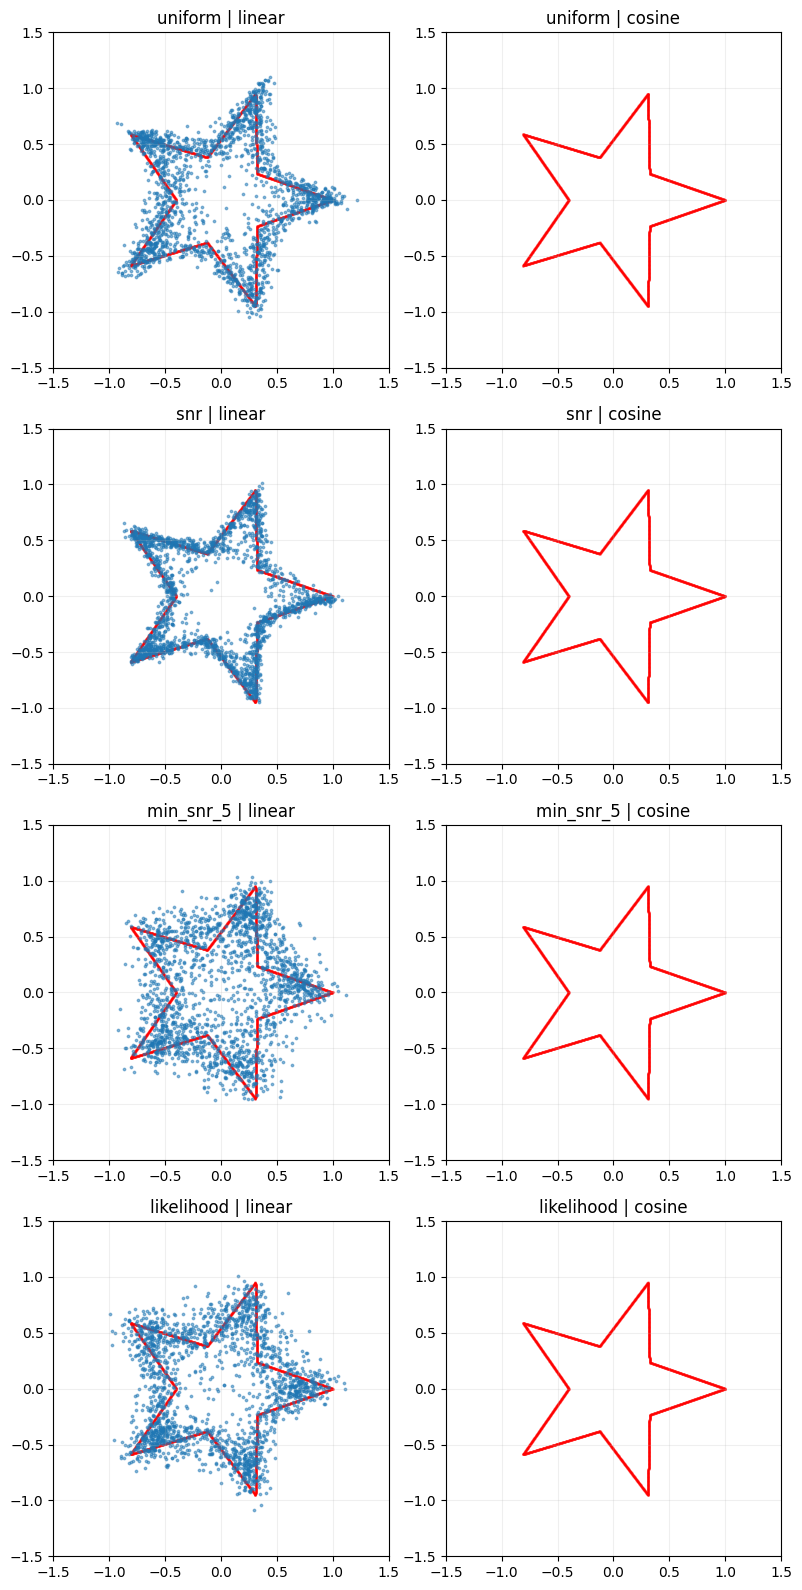

In [13]:
fig, axes = plt.subplots(len(weight_names), len(schedules), figsize=(4 * len(schedules), 4 * len(weight_names)))

for r, wn in enumerate(weight_names):
    for c, sch in enumerate(schedules):
        ax = axes[r][c]
        pts = results[f'{sch}_{wn}']['samples']
        ax.scatter(target[:, 0], target[:, 1], s=1, alpha=0.15, c='red')
        ax.scatter(pts[:, 0], pts[:, 1], s=3, alpha=0.5, c='C0')
        ax.set_title(f'{wn} | {sch}')
        ax.set_xlim(-1.5, 1.5)
        ax.set_ylim(-1.5, 1.5)
        ax.set_aspect('equal')
        ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

## Выводы

**Расписание (линейное vs косинусное).** Косинусное расписание медленнее разрушает сигнал на ранних t (ᾱ убывает плавнее), поэтому в середине процесса модель видит больше уровней зашумления с осмысленным сигналом. На двумерной звёздочке эффект слабее, чем на изображениях, но косинус даёт чуть лучшее покрытие острых лучей и меньше «размытости» по контуру за счёт более равномерного бюджета шума по t. Линейное расписание чуть быстрее уводит сигнал в чистый шум и теряет тонкую структуру кончиков.

**Перевзвешивание лосса.**
- *uniform* — стабильный baseline. ε-параметризация уже неявно содержит SNR-взвешивание относительно x₀-лосса, поэтому простая равномерная схема даёт приличный результат.
- *snr* (clamped at 5) — усиливает фокус на t близких к 0 (низкий шум). Помогает деталям контура, но рискует «забить» обучение средне-шумных шагов, что мешает восстановлению глобальной формы.
- *min_snr_5* — компромисс из Hang et al. 2023: режет переусиление низкошумных шагов, балансирует обучение по всем t. Эмпирически самый стабильный вариант на обоих расписаниях, кончики звезды выглядят чётко, шум вокруг минимальный.
- *likelihood* (w = β(t)) — ELBO-подобный вес, β растёт по t и фокус смещается на сильно зашумлённые шаги; глобальная форма ловится, но мелкая структура смазана и кончики лучей плывут.

Сравнение абсолютных значений лосса между схемами некорректно — у них разные шкалы веса. Смотрим в первую очередь на визуальное качество сэмплов.

**Лучшая комбинация:** cosine + min_snr_5 — чёткие лучи и стабильное обучение. Линейное расписание с uniform — простейший рабочий вариант (фактически DDPM L_simple под VP-SDE).